In [3]:
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import json
import os

from demo_db import get_db_url

load_dotenv()

ukrdc3_sessionmaker = sessionmaker(
    autocommit=False, autoflush=False, bind=create_engine(get_db_url())
)

ukrdc3 = ukrdc3_sessionmaker()


# Patients Treatment Statistics
The following shows how to generate some statistics demonstrating the propotion of patients on home therapies. These are calculated from June 2021 to June 2022 and show the breakdown of the different dialysis types as well as the treatment is occuring at home or in centre. 

The final histogram shows the mean number of times each in-centre dialysis patient recieves RRT. Statistics like this can be used to show the general compsition of the patients and the treatments they are receiving.  

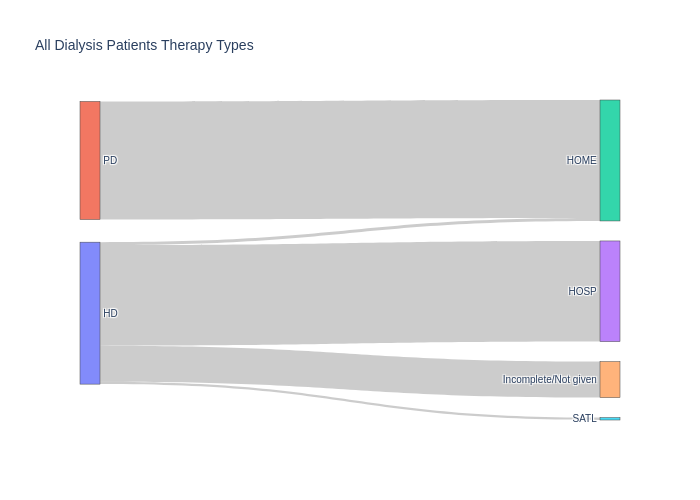

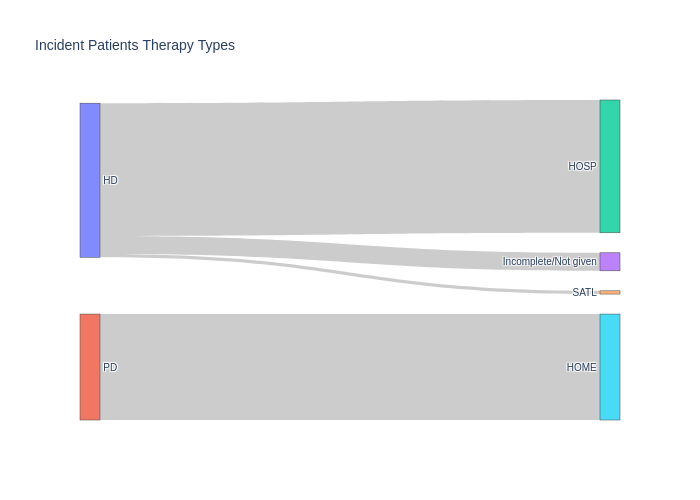

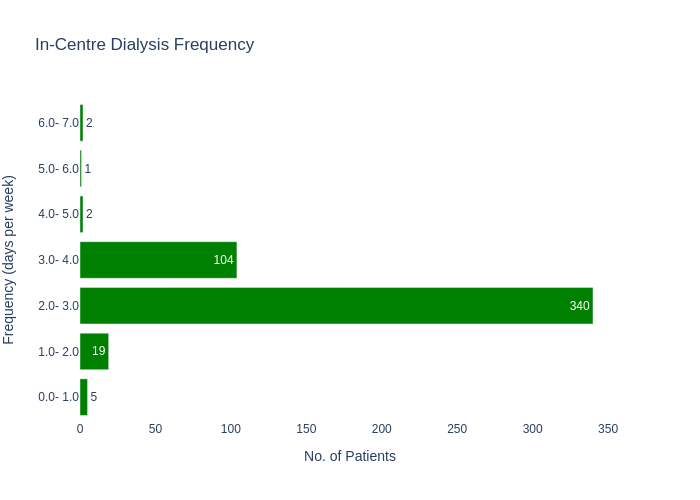

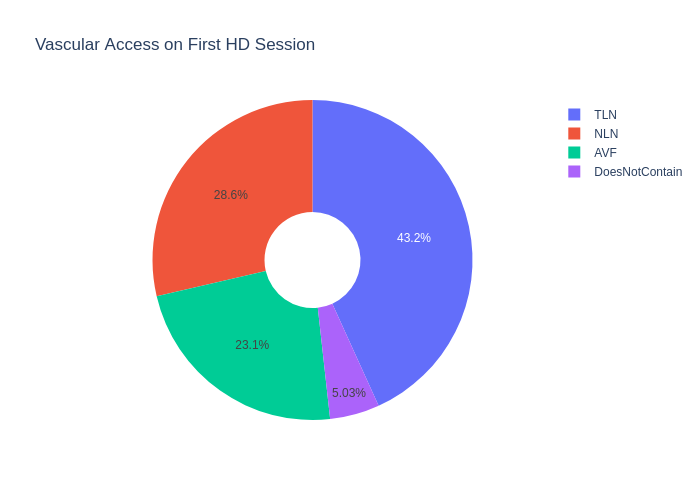

In [5]:
from os import access
from ukrdc_stats.calculators.dialysis import DialysisStatsCalculator
import plotly.graph_objects as go
import plotly.express as px

import datetime as dt
from IPython.display import display

calculator = DialysisStatsCalculator(
    ukrdc3, "RNJ00", from_time=dt.datetime(2018, 12, 31), to_time=dt.datetime(2019, 12, 31)
)

dialysis_stats = calculator.extract_stats()


all_patients_fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                label=dialysis_stats.all_patients_home_therapies.node.node_labels,
            ),
            link=dialysis_stats.all_patients_home_therapies.link.dict(),
        )
    ]
)

all_patients_fig.update_layout(
    title_text=dialysis_stats.all_patients_home_therapies.metadata.title, font_size=10
)
all_patients_fig.show("png")
all_patients_fig.write_image("all_patients.pdf")


incident_patients_fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                label=dialysis_stats.incident_home_therapies.node.node_labels,
            ),
            link=dialysis_stats.incident_home_therapies.link.dict(),
        )
    ]
)

incident_patients_fig.update_layout(
    title_text=dialysis_stats.incident_home_therapies.metadata.title, font_size=10
)
incident_patients_fig.show("png")
incident_patients_fig.write_image("incident_patients.pdf")


prevalent_patients_fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                label=dialysis_stats.prevalent_home_therapies.node.node_labels,
            ),
            link=dialysis_stats.prevalent_home_therapies.link.dict(),
        )
    ]
)


prevalent_patients_fig.update_layout(
    title_text=dialysis_stats.prevalent_home_therapies.metadata.title, font_size=10
)
prevalent_patients_fig.show()
prevalent_patients_fig.write_image("prevalent_patients_fig.pdf")


freq_fig = px.bar(
    x=dialysis_stats.incentre_dialysis_frequency.data.y,
    y=dialysis_stats.incentre_dialysis_frequency.data.x,
    title=dialysis_stats.incentre_dialysis_frequency.metadata.title,
    labels={
        "x": dialysis_stats.incentre_dialysis_frequency.metadata.axis_titles.y,
        "y": dialysis_stats.incentre_dialysis_frequency.metadata.axis_titles.x,
    },
    orientation="h",
    color_discrete_sequence=["green"],
    text_auto=True,
)

# set white background
freq_fig.update_layout({"plot_bgcolor": "rgba(0,0,0,0)"})

freq_fig.show("png")
freq_fig.write_image("freq_fig.pdf")


access_fig = px.pie(
    values=dialysis_stats.incident_initial_access.data.y,
    names=dialysis_stats.incident_initial_access.data.x,
    title=dialysis_stats.incident_initial_access.metadata.title,
    hole=0.3,
)
access_fig.show("png")
access_fig.write_image("access_fig.pdf")


# Patient Biomarker Statistics

**Note:** This section is currently not operational. Code related to biomarker stats was removed temporarily for a refactor and will be added back soon.

The following code shows some of the more granular statisics which can be produced using the data in the UKRDC. Here the eGFR results over a year can be plotted. These are harder to present in meaniful way but show how the data could be displayed to allow more microscopic insights to be generated. 

The bottom test shows all the eGFR in the given time period. From these results a breakdown of the CKD stage based on the most recent eGFR result of each patient. 

In [ ]:
biomarker_results = calculator.extract_biomarkers()

AttributeError: 'DialysisStatsCalculator' object has no attribute 'extract_biomarkers'

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np


CKD_stage = px.pie(
    values=biomarker_results.CKD_stage.data.y,
    names=biomarker_results.CKD_stage.data.x,
    title=biomarker_results.CKD_stage.metadata.title,
    hole=0.3,
)
CKD_stage.show("png")


egfr_data = pd.DataFrame(
    list(
        zip(
            biomarker_results.prevalent_patients_egfr.x,
            [5 * i for i in range(len(biomarker_results.prevalent_patients_egfr.x))],
            biomarker_results.prevalent_patients_egfr.z,
        )
    ),
    columns=["date", "y", "eGFR"],
)

egfr_fig = px.scatter(
    egfr_data,
    x="date",
    y="y",
    color="eGFR",
    color_continuous_scale=px.colors.sequential.Inferno,
    range_color=[0, 30],
    #
    color_continuous_midpoint=15,
)

egfr_fig.update_layout({"plot_bgcolor": "rgba(0,0,0,0)"}, width=600, height=600)
egfr_fig.update_yaxes(visible=False)
egfr_fig.show("png")


print(min(egfr_data["eGFR"]))


NameError: name 'biomarker_results' is not defined

# Time and Memory Usage
The next block of code will profile some of the time and memory usage of the stats calculated in this Demo. 

The main memory bottlenecks are the dataframes which store the query which is run on the ukrdc. These queries are also the main time bottleneck (note the extract_stats call now takes slightly longer to run than the initialisation call because I had to introduce some database queries for some of more complicated stats). 

In [ ]:
from contextlib import contextmanager
from time import perf_counter, sleep
from typing import Generator
import numpy as np


@contextmanager
def catchtime():
    start = perf_counter()
    yield lambda: perf_counter() - start


no_function_calls = 10
time_init = []
time_calc = []
memory = []


for i in range(no_function_calls):
    with catchtime() as t:
        calculator = DialysisStatsCalculator(
            ukrdc3,
            "RNJ00",
            from_time=dt.datetime(2020, 6, 1),
            to_time=dt.datetime(2021, 6, 1),
        )
    time_init.append(t())
    with catchtime() as t:
        dialysis_stats = calculator.extract_stats()
    time_calc.append(t())
    if calculator._patient_cohort is not None:
        memory.append(
            np.sum(calculator._patient_cohort.memory_usage().to_numpy()) / 1.0e6
        )


print(
    f"Average time to initialise the calculator object over {no_function_calls} calls: {np.sum(time_init)/no_function_calls:.3f} secs"
)
print(
    f"Average time to run and extract stats calculations {no_function_calls} calls: {np.sum(time_calc)/no_function_calls:.3f} secs"
)
print(
    f"Average memory used by patient_cohort dataframe over {no_function_calls} calls {np.sum(memory)/no_function_calls:.3f} Mb"
)


: 

# 